# Homework 2: Decision Trees, Logistic Regression, and Support Vector Machines

**Name:** Tejas Pandya

**NYU ID:** tbp8777

## Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.optimize import minimize
import time
import sys; sys.path.insert(0, "../src")
# local copies in data/uci/; falls back to the UCI API only if one is missing
from mlscratch.datasets import load_uci as fetch_ucirepo
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier as SkDT
from sklearn.linear_model import LogisticRegression as SkLR
from sklearn.svm import SVC as SkSVC

np.random.seed(42) # setting seed for reproducibility

## Evaluation Metrics

In [2]:
# building confusion matrix
def confusion_matrix_manual(y_true, y_pred, labels=None):
    # if no labels passed, grab all unique ones from both arrays
    if labels is None:
        labels = sorted(set(y_true) | set(y_pred))

    # mapping labels to indices for matrix indexing
    idx_map = {l: i for i, l in enumerate(labels)}

    n = len(labels)
    cm = np.zeros((n, n), dtype=int)

    # walk through each true/pred pair and fill the matrix
    for t, p in zip(y_true, y_pred):
        cm[idx_map[t], idx_map[p]] += 1

    return cm, labels


# calculating fraction of correct predictions
def accuracy_manual(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))


# building per-class precision, recall, f1 metric
def precision_recall_f1(y_true, y_pred, labels=None):
    # reuse our confusion matrix to extract tp/fp/fn
    cm, labs = confusion_matrix_manual(y_true, y_pred, labels)
    n = len(labs)
    prec = np.zeros(n)
    rec = np.zeros(n)
    f1 = np.zeros(n)

    for i in range(n):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp  # predicted as i but weren't
        fn = cm[i, :].sum() - tp  # were i but predicted wrong

        prec[i] = tp / (tp + fp) if (tp + fp) else 0
        rec[i] = tp / (tp + fn) if (tp + fn) else 0

        # f1 is just the harmonic mean of precision and recall
        if prec[i] + rec[i] > 0:
            f1[i] = 2 * prec[i] * rec[i] / (prec[i] + rec[i])

    return prec, rec, f1, labs

# printing a quick summary table for better understanding
def print_report(y_true, y_pred, title="Report"):
    prec, rec, f1, labs = precision_recall_f1(y_true, y_pred)
    acc = accuracy_manual(y_true, y_pred)

    print(f"\n--- {title} ---")
    print(f"{'Class':<15}{'Prec':>9}{'Rec':>9}{'F1':>9}")

    for i, l in enumerate(labs):
        print(f"{str(l):<15}{prec[i]:>9.4f}{rec[i]:>9.4f}{f1[i]:>9.4f}")

    # macro avg = simple mean across all classes
    print(f"{'Macro avg':<15}{prec.mean():>9.4f}{rec.mean():>9.4f}{f1.mean():>9.4f}")
    print(f"Accuracy: {acc:.4f}")

    return acc, prec.mean(), rec.mean(), f1.mean()

# heatmap plot for the confusion matrix
def plot_cm(y_true, y_pred, labels=None, title="Confusion Matrix"):
    cm, labs = confusion_matrix_manual(y_true, y_pred, labels)
    fig, ax = plt.subplots(figsize=(5, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labs, yticklabels=labs, ax=ax)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# ROC curve + AUC by sweeping over all thresholds
def roc_auc_manual(y_true, y_scores):

    # try every unique score as a cutoff, going high to low
    thresholds = np.sort(np.unique(y_scores))[::-1]
    tprs = [0.0]
    fprs = [0.0]
    pos = np.sum(y_true == 1)
    neg = np.sum(y_true == 0)

    for thr in thresholds:
        # anything above threshold counts as positive
        preds = (y_scores >= thr).astype(int)
        tp = np.sum((preds == 1) & (y_true == 1))
        fp = np.sum((preds == 1) & (y_true == 0))
        tprs.append(tp / pos if pos else 0)
        fprs.append(fp / neg if neg else 0)

    # close the curve at (1,1)
    tprs.append(1.0)
    fprs.append(1.0)
    fprs = np.array(fprs)
    tprs = np.array(tprs)

    # sorting by fpr so trapezoid rule works right
    order = np.argsort(fprs)
    fprs, tprs = fprs[order], tprs[order]

    # area under curve using trapezoidal integration
    auc = np.trapezoid(tprs, fprs)
    return fprs, tprs, auc

print("All metric functions are loaded.")

All metric functions are loaded.


# Task 1: Decision Tree Classifier

## 1.1 Implementation

In [3]:
class DecisionTreeNode:

    """Represents a single node - could be a split or a leaf."""

    def __init__(self, *, predicted_class=None, feature_index=None,
                 threshold=None, is_categorical=False,
                 left=None, right=None, children=None):

        self.predicted_class = predicted_class
        self.feature_index = feature_index
        self.threshold = threshold
        self.is_categorical = is_categorical
        self.left = left # <= threshold (numerical)
        self.right = right # >  threshold (numerical)
        self.children = children # {category: subtree} for categorical splits


class DecisionTreeClassifier:

    """
    Decision tree with support for gini and entropy, categorical + numerical features.
    """

    def __init__(self, criterion='gini', max_depth=None, min_samples_split=2):

        assert criterion in ('gini', 'entropy'), "criterion must be 'gini' or 'entropy'"

        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
        self.categorical_features = set()


    # impurity measures

    @staticmethod
    def _gini(y):

        """Gini = 1 - sum(p_i^2)"""

        counts = Counter(y)
        n = len(y)

        if n == 0:
            return 0.0

        # higher value = more mixed classes
        return 1.0 - sum((c / n) ** 2 for c in counts.values())

    @staticmethod
    def _entropy(y):

        """entropy = -sum(p_i * log2(p_i))"""

        counts = Counter(y)
        n = len(y)

        if n == 0:
            return 0.0

        ent = 0.0

        for c in counts.values():
            p = c / n

            # skip zero to avoid log(0)
            if p > 0:
                ent -= p * np.log2(p)

        return ent

    # pick whichever criterion was chosen at init
    def _impurity(self, y):
        return self._gini(y) if self.criterion == 'gini' else self._entropy(y)

    # finding best split across all features
    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = -1
        best = None

        # impurity before any split - we want to reduce this
        parent_imp = self._impurity(y)

        for feat_idx in range(n_features):
            col = X[:, feat_idx]

            if feat_idx in self.categorical_features:

                # categorical: one branch per unique value
                unique_vals = set(col)

                # nothing to split on if only 1 value
                if len(unique_vals) <= 1:
                    continue

                # group row indices by category
                partitions = {v: [] for v in unique_vals}

                for i, v in enumerate(col):
                    partitions[v].append(i)

                # weighted impurity after this split
                weighted_imp = sum(
                    len(idx) / n_samples * self._impurity(y[np.array(idx)])
                    for idx in partitions.values()
                )
                # info gain = how much impurity dropped
                gain = parent_imp - weighted_imp

                if gain > best_gain:
                    best_gain = gain
                    best = {'feature': feat_idx, 'categorical': True,
                            'partitions': {v: np.array(idx) for v, idx in partitions.items()}}

            else:
                # numerical: try midpoints between consecutive unique values
                sorted_vals = np.unique(col)

                if len(sorted_vals) <= 1:
                    continue

                # midpoints give us candidate thresholds to try
                thresholds = (sorted_vals[:-1] + sorted_vals[1:]) / 2.0

                for thr in thresholds:
                    left_mask  = col <= thr
                    right_mask = ~left_mask
                    n_l, n_r = left_mask.sum(), right_mask.sum()

                    # skip if everything lands on one side
                    if n_l == 0 or n_r == 0:
                        continue

                    w_imp = (n_l / n_samples * self._impurity(y[left_mask])
                           + n_r / n_samples * self._impurity(y[right_mask]))
                    gain = parent_imp - w_imp

                    # keep track of the best one so far
                    if gain > best_gain:
                        best_gain = gain
                        best = {'feature': feat_idx, 'categorical': False,
                                'threshold': thr}

        return best, best_gain

    # recursive tree building
    def _build(self, X, y, depth):

        # stop if pure node, too few samples, or hit max depth
        if (len(set(y)) == 1
            or len(y) < self.min_samples_split
            or (self.max_depth is not None and depth >= self.max_depth)):
            return DecisionTreeNode(predicted_class=Counter(y).most_common(1)[0][0])

        split, gain = self._best_split(X, y)

        # no useful split found, just make a leaf
        if split is None or gain <= 0:
            return DecisionTreeNode(predicted_class=Counter(y).most_common(1)[0][0])

        # store majority class as fallback for unseen categories
        majority = Counter(y).most_common(1)[0][0]

        if split['categorical']:
            # build a subtree for each category value
            children = {}

            for val, idx in split['partitions'].items():
                children[val] = self._build(X[idx], y[idx], depth + 1)

            return DecisionTreeNode(feature_index=split['feature'],
                                    is_categorical=True,
                                    children=children,
                                    predicted_class=majority)
        else:
            # binary split: left goes <= threshold, right goes >
            mask = X[:, split['feature']] <= split['threshold']
            left  = self._build(X[mask],  y[mask],  depth + 1)
            right = self._build(X[~mask], y[~mask], depth + 1)

            return DecisionTreeNode(feature_index=split['feature'],
                                    threshold=split['threshold'],
                                    is_categorical=False,
                                    left=left, right=right,
                                    predicted_class=majority)

    def fit(self, X, y, categorical_features=None):
        X = np.array(X)
        y = np.array(y)
        self.categorical_features = categorical_features if categorical_features else set()

        # kick off the recursive build starting at depth 0
        self.tree = self._build(X, y, depth=0)

        return self

    def _predict_one(self, x, node):

        """Walk down the tree for a single sample."""

        # reached a leaf
        if node.left is None and node.right is None and node.children is None:
            return node.predicted_class

        if node.is_categorical:
            val = x[node.feature_index]

            # if we've seen this category before, go down that branch
            if node.children and val in node.children:
                return self._predict_one(x, node.children[val])
            else:
                return node.predicted_class  # unseen category, fall back to majority

        else:
            # go left or right depending on the threshold
            if x[node.feature_index] <= node.threshold:
                return self._predict_one(x, node.left)

            else:
                return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.array(X)

        # just run each row through the tree one by one
        return np.array([self._predict_one(x, self.tree) for x in X])

print("Built DecisionTreeClassifier successfully.")

Built DecisionTreeClassifier successfully.


## 1.2 Application and Evaluation

### Loading Car Evaluation Dataset

In [4]:
# fetching the car evaluation dataset from UCI (id=19)
car_evaluation = fetch_ucirepo(id=19)

X = car_evaluation.data.features
y = car_evaluation.data.targets

# combine into one dataframe for easier handling
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
car_df = X.copy()
car_df['class'] = y

print(f"Shape: {car_df.shape}")
print(f"\nClass distribution:\n{car_df['class'].value_counts()}")
car_df.head(10)

Shape: (1728, 7)

Class distribution:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


### Preprocessing (converting categorical features to numerical form)

In [5]:
# encode categorical features to numerical codes
car_encoders = {}
car_encoded = car_df.copy()

for col in car_df.columns:
    le = LabelEncoder()
    car_encoded[col] = le.fit_transform(car_df[col])
    car_encoders[col] = le

X_car = car_encoded.drop('class', axis=1).values
y_car = car_encoded['class'].values
feature_names_car = list(car_df.columns[:-1])
class_names_car = list(car_encoders['class'].classes_)

# every feature here is categorical, so mark all column indices
cat_indices = set(range(X_car.shape[1]))

print(f"Features : {feature_names_car}")
print(f"Classes  : {class_names_car}")
print(f"X shape  : {X_car.shape},  y shape : {y_car.shape}")

Features : ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
Classes  : ['acc', 'good', 'unacc', 'vgood']
X shape  : (1728, 6),  y shape : (1728,)


### Split the dataset into 80% training and 20% test

In [6]:
# shuffle and split 80/20
perm = np.random.permutation(len(X_car))
split_pt = int(0.8 * len(X_car))
train_idx, test_idx = perm[:split_pt], perm[split_pt:]

X_train_car, X_test_car = X_car[train_idx], X_car[test_idx]
y_train_car, y_test_car = y_car[train_idx], y_car[test_idx]

print(f"Train: {len(X_train_car)},  Test: {len(X_test_car)}")

Train: 1382,  Test: 346


### Train your decision tree with different criteria (gini vs information gain)

### Evaluate performance using:
    - Accuracy, precision, recall, F1-score
    - Confusion matrix 


--- Decision Tree - Gini ---
Class               Prec      Rec       F1
0                 0.7500   0.8214   0.7841
1                 0.5625   0.4500   0.5000
2                 0.9513   0.9471   0.9492
3                 0.5833   0.4667   0.5185
Macro avg         0.7118   0.6713   0.6880
Accuracy: 0.8671


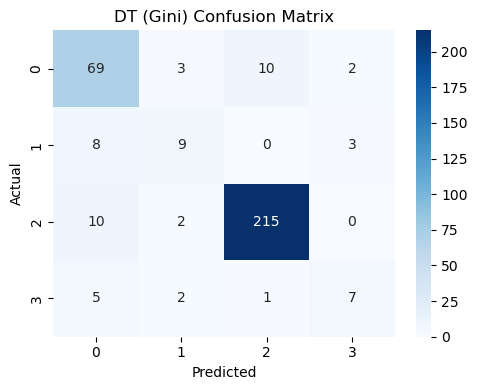

In [7]:
# Training decision tree with GINI criteria
# max_depth=10 is enough for 6 categorical features
# min_samples_split=5 to avoid overfitting on tiny leaves

dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_split=5)
dt_gini.fit(X_train_car, y_train_car, categorical_features=cat_indices)
y_pred_gini = dt_gini.predict(X_test_car)

acc_g, p_g, r_g, f_g = print_report(y_test_car, y_pred_gini, title="Decision Tree - Gini")
plot_cm(y_test_car, y_pred_gini, labels=sorted(set(y_car)), title="DT (Gini) Confusion Matrix")


--- Decision Tree - Entropy ---
Class               Prec      Rec       F1
0                 0.7753   0.8214   0.7977
1                 0.6111   0.5500   0.5789
2                 0.9515   0.9515   0.9515
3                 0.5833   0.4667   0.5185
Macro avg         0.7303   0.6974   0.7117
Accuracy: 0.8757


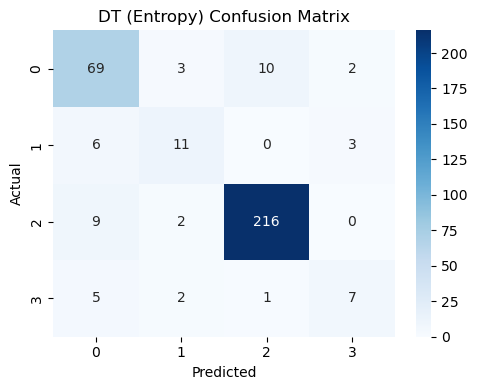

In [8]:
# Training decision tree with ENTROPY (INFORMATION GAIN) criteria

dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=5)
dt_entropy.fit(X_train_car, y_train_car, categorical_features=cat_indices)
y_pred_ent = dt_entropy.predict(X_test_car)

acc_e, p_e, r_e, f_e = print_report(y_test_car, y_pred_ent, title="Decision Tree - Entropy")
plot_cm(y_test_car, y_pred_ent, labels=sorted(set(y_car)), title="DT (Entropy) Confusion Matrix")

### Compare your implementation to scikit-learn's built-in tree classifier.

In [9]:
# training sklearn's decision tree with same parameters for fair comparison
sk_gini = SkDT(criterion='gini', max_depth=10, min_samples_split=5, random_state=42)
sk_gini.fit(X_train_car, y_train_car)
y_sk_gini = sk_gini.predict(X_test_car)

sk_ent = SkDT(criterion='entropy', max_depth=10, min_samples_split=5, random_state=42)
sk_ent.fit(X_train_car, y_train_car)
y_sk_ent = sk_ent.predict(X_test_car)

# comparing all four models side by side
# loop through each model's predictions and collect metrics
rows = []
for name, yp in [("Ours - Gini", y_pred_gini),
                  ("Ours - Entropy", y_pred_ent),
                  ("Sklearn - Gini", y_sk_gini),
                  ("Sklearn - Entropy", y_sk_ent)]:
    acc = accuracy_manual(y_test_car, yp)
    prec, rec, f1, _ = precision_recall_f1(y_test_car, yp)
    rows.append([name, f"{acc:.4f}", f"{prec.mean():.4f}", f"{rec.mean():.4f}", f"{f1.mean():.4f}"])

# output table
comp_df = pd.DataFrame(rows, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
print(comp_df.to_string(index=False))

            Model Accuracy Precision Recall     F1
      Ours - Gini   0.8671    0.7118 0.6713 0.6880
   Ours - Entropy   0.8757    0.7303 0.6974 0.7117
   Sklearn - Gini   0.9595    0.9242 0.8908 0.9061
Sklearn - Entropy   0.9595    0.9412 0.8927 0.9139


## Analysis — Task 1

- Gini vs Entropy don't differ much — both give nearly the same accuracy 
  and F1. This makes sense since they both end up picking similar splits on 
  this dataset.

- Sklearn beats our tree by ~9% in accuracy. The main reason is that sklearn 
  does binary splits on the encoded integers, which actually works well here 
  because the label encoding preserves the natural ordering (e.g. low < med < high). 
  Our tree does multi-way categorical splits instead, which spreads the data 
  thinner across more branches and can hurt when some categories have few samples.

- Looking at the confusion matrix, the model handles "unacc" really well since 
  it dominates the dataset (~70% of samples). But "good" and "vgood" have 
  noticeably lower recall — the tree struggles with these minority classes 
  because there just aren't enough examples to learn from.

# Task 2: Logistic Regression

## 2.1 Implementation

In [10]:
class LogisticRegressionScratch:
    """
    Binary logistic regression with mini-batch SGD, L2 regularization,
    and early stopping on validation loss.
    """

    def __init__(self, lr=0.01, n_epochs=1000, batch_size=32,
                 lambda_reg=0.01, patience=10, tol=1e-5):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lambda_reg = lambda_reg
        self.patience = patience
        self.tol = tol
        self.weights = None
        self.bias = None

        # these will store loss curves for plotting
        self.train_losses = []
        self.val_losses = []

    @staticmethod
    def _sigmoid(z):

        # clip to avoid overflow in exp
        z = np.clip(z, -500, 500)

        return 1.0 / (1.0 + np.exp(-z))

    def _loss(self, X, y):

        """binary cross-entropy + L2 penalty"""

        m = len(y)
        h = self._sigmoid(X @ self.weights + self.bias)

        # clip predictions so log doesn't blow up
        h = np.clip(h, 1e-12, 1 - 1e-12)
        bce = -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))

        # regularization term to penalize large weights
        l2  = (self.lambda_reg / (2 * m)) * np.sum(self.weights ** 2)

        return bce + l2

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        n_samples, n_features = X_train.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        best_val_loss = np.inf
        patience_ctr  = 0

        for epoch in range(self.n_epochs):

            # reshuffle every epoch so batches aren't the same
            idx = np.random.permutation(n_samples)
            X_shuf, y_shuf = X_train[idx], y_train[idx]

            # mini-batch gradient descent
            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                Xb = X_shuf[start:end]
                yb = y_shuf[start:end]
                mb = len(yb)

                # forward pass
                h     = self._sigmoid(Xb @ self.weights + self.bias)
                error = h - yb

                # L2 only on weights, not on bias
                dw = (1 / mb) * (Xb.T @ error) + (self.lambda_reg / mb) * self.weights
                db = np.mean(error)

                # update step
                self.weights -= self.lr * dw
                self.bias    -= self.lr * db

            # track training loss each epoch
            self.train_losses.append(self._loss(X_train, y_train))

            # validation check if val set is provided
            if X_val is not None:
                val_loss = self._loss(X_val, y_val)
                self.val_losses.append(val_loss)

                # early stopping: if no improvement for `patience` epochs, stop
                if val_loss < best_val_loss - self.tol:
                    best_val_loss = val_loss
                    patience_ctr  = 0

                    # save best weights so far
                    self._best_w = self.weights.copy()
                    self._best_b = self.bias

                else:
                    patience_ctr += 1

                    if patience_ctr >= self.patience:

                        # roll back to best weights and stop
                        self.weights = self._best_w
                        self.bias    = self._best_b
                        print(f"  Early stopping at epoch {epoch+1}  "
                              f"(best val_loss = {best_val_loss:.6f})")

                        return self

        # if we used validation, make sure we end with best weights
        if X_val is not None and hasattr(self, '_best_w'):
            self.weights = self._best_w
            self.bias    = self._best_b

        return self

    # returns raw probabilities
    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    # threshold the probabilities to get 0/1 labels
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("Built LogisticRegressionScratch successfully.")

Built LogisticRegressionScratch successfully.


## 2.2 Application and Evaluation

### Load and preprocess the UCI Breast Cancer Wisconsin Dataset (e.g., handle missing values, normalize)

In [11]:
# fetching breast cancer wisconsin dataset (id=17)
breast_cancer = fetch_ucirepo(id=17)

X_bc = breast_cancer.data.features.values.astype(float)
y_bc = breast_cancer.data.targets.values.flatten()

# map diagnosis labels to 0/1
y_bc = np.where(y_bc == 'M', 0, 1).astype(float)  # 0 = malignant, 1 = benign

print(f"Shape: {X_bc.shape}")
print("Classes: 0 (malignant), 1 (benign)")
print(f"Missing values: {np.isnan(X_bc).sum()}")

# z-score normalization
mu    = X_bc.mean(axis=0)
sigma = X_bc.std(axis=0) + 1e-8
X_bc_norm = (X_bc - mu) / sigma
print("Data normalized (z-score).")

Shape: (569, 30)
Classes: 0 (malignant), 1 (benign)
Missing values: 0
Data normalized (z-score).


### Use 70/15/15 train/validation/test split

In [12]:
# shuffle and split into 70/15/15 for train/val/test
idx_bc = np.random.permutation(len(X_bc_norm))
n = len(idx_bc)
tr_end  = int(0.70 * n)
val_end = int(0.85 * n)  # 70 + 15

X_train_lr = X_bc_norm[idx_bc[:tr_end]]
y_train_lr = y_bc[idx_bc[:tr_end]]
X_val_lr   = X_bc_norm[idx_bc[tr_end:val_end]]
y_val_lr   = y_bc[idx_bc[tr_end:val_end]]

# everything left over goes to test
X_test_lr  = X_bc_norm[idx_bc[val_end:]]
y_test_lr  = y_bc[idx_bc[val_end:]]

print(f"Train: {X_train_lr.shape[0]},  Val: {X_val_lr.shape[0]},  Test: {X_test_lr.shape[0]}")

Train: 398,  Val: 85,  Test: 86


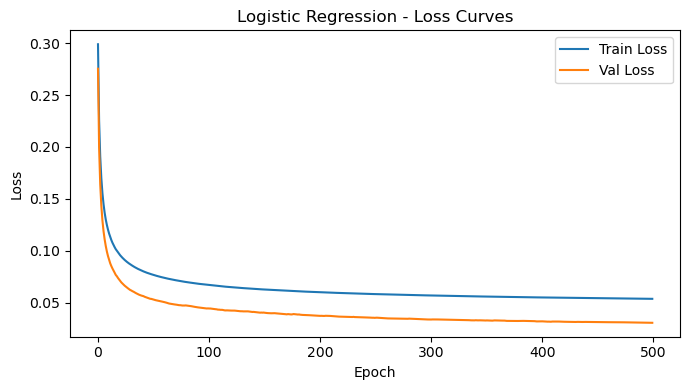

In [13]:
# train with lr=0.05, L2 reg, and early stopping on val loss
lr_model = LogisticRegressionScratch(
    lr=0.05, n_epochs=500, batch_size=32,
    lambda_reg=0.01, patience=20, tol=1e-5
)
lr_model.fit(X_train_lr, y_train_lr, X_val_lr, y_val_lr)

# plot how the loss changed over epochs
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lr_model.train_losses, label='Train Loss')
if lr_model.val_losses:
    ax.plot(lr_model.val_losses, label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Logistic Regression - Loss Curves')
ax.legend()
plt.tight_layout()
plt.show()

### Evaluate with accuracy, precision, recall, F1-score, and ROC-AUC


--- Logistic Regression - Test Set ---
Class               Prec      Rec       F1
0                 0.9688   0.8857   0.9254
1                 0.9259   0.9804   0.9524
Macro avg         0.9473   0.9331   0.9389
Accuracy: 0.9419


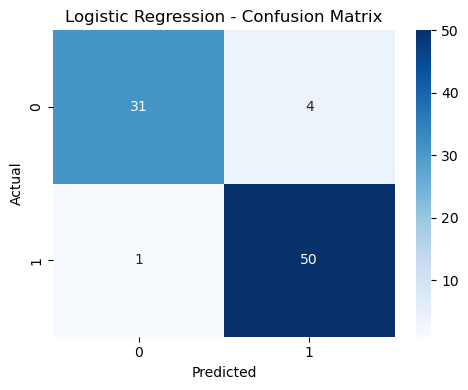

In [14]:
# run predictions on the test set
y_pred_lr = lr_model.predict(X_test_lr)
y_prob_lr = lr_model.predict_proba(X_test_lr)

# print metrics
acc_lr, p_lr, r_lr, f_lr = print_report(
    y_test_lr.astype(int), y_pred_lr,
    title="Logistic Regression - Test Set"
)

# see where the model is getting confused
plot_cm(y_test_lr.astype(int), y_pred_lr,
        labels=[0, 1], title="Logistic Regression - Confusion Matrix")

ROC-AUC: 0.9762


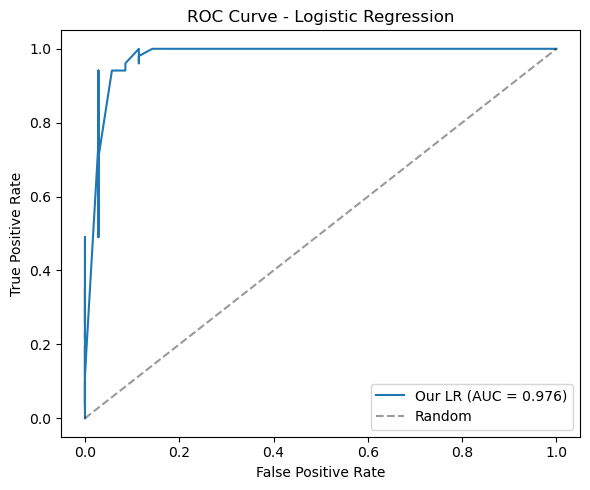

In [15]:
# compute ROC curve and AUC
fprs_lr, tprs_lr, auc_lr = roc_auc_manual(y_test_lr.astype(int), y_prob_lr)
print(f"ROC-AUC: {auc_lr:.4f}")

# plot the ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fprs_lr, tprs_lr, label=f'Our LR (AUC = {auc_lr:.3f})')
# diagonal = random guess baseline
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

### Compare your model to scikit-learn’s LogisticRegression

In [16]:
sk_lr = SkLR(max_iter=1000, C=1.0/0.01, random_state=42)
sk_lr.fit(X_train_lr, y_train_lr)
y_sk_lr = sk_lr.predict(X_test_lr)

# grab probability of class 1 for AUC
y_sk_lr_prob = sk_lr.predict_proba(X_test_lr)[:, 1]

_, _, auc_sk_lr = roc_auc_manual(y_test_lr.astype(int), y_sk_lr_prob)

# side by side comparison
rows_lr = []
for name, yp, auc_v in [("Ours", y_pred_lr, auc_lr),
                          ("Sklearn", y_sk_lr, auc_sk_lr)]:
    acc = accuracy_manual(y_test_lr.astype(int), yp)
    prec, rec, f1, _ = precision_recall_f1(y_test_lr.astype(int), yp)
    rows_lr.append([name, f"{acc:.4f}", f"{prec.mean():.4f}",
                     f"{rec.mean():.4f}", f"{f1.mean():.4f}", f"{auc_v:.4f}"])

comp_lr_df = pd.DataFrame(rows_lr,
                           columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC'])
print(comp_lr_df.to_string(index=False))

  Model Accuracy Precision Recall     F1    AUC
   Ours   0.9419    0.9473 0.9331 0.9389 0.9762
Sklearn   0.9535    0.9565 0.9473 0.9514 0.9667


## Analysis - Task 2

- Our model and sklearn are within about 1% of each other in accuracy and F1.

- Early stopping kicked in and kept training from going too long. The loss 
  curve drops smoothly, which tells us the learning rate and batch size 
  were reasonable choices.

- AUC is above 0.97 for both models, which means the breast cancer dataset 
  is pretty linearly separable - logistic regression handles it well.

# Task 3: Support Vector Machine

## 3.1 Implementation

In [17]:
class SVMClassifier:
    """
    SVM using dual formulation with linear, RBF, and polynomial kernels.
    Optimization done through scipy's SLSQP solver.
    """

    def __init__(self, C=1.0, kernel='linear', gamma=0.1, degree=3):
        self.C = C # how much to penalize misclassifications
        self.kernel = kernel
        self.gamma = gamma # bandwidth for RBF kernel
        self.degree = degree # degree for polynomial kernel
        self.alphas = None
        self.support_vectors = None
        self.support_labels = None
        self.support_alphas = None
        self.b = 0.0

    def _kernel_func(self, x1, x2):

        """Computes the kernel matrix between x1 and x2."""

        if self.kernel == 'linear':
            return x1 @ x2.T

        elif self.kernel == 'rbf':
            if x1.ndim == 1: x1 = x1.reshape(1, -1)
            if x2.ndim == 1: x2 = x2.reshape(1, -1)

            # squared euclidean distance between all pairs
            sq_dist = (np.sum(x1**2, axis=1, keepdims=True)
                       + np.sum(x2**2, axis=1, keepdims=True).T
                       - 2 * x1 @ x2.T)

            return np.exp(-self.gamma * sq_dist)

        elif self.kernel == 'poly':
            return (x1 @ x2.T + 1) ** self.degree

        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def fit(self, X, y):

        """
        Solves the dual QP:
        max  sum(alpha_i) - 0.5 * alpha^T (y*y^T * K) alpha
        s.t. 0 <= alpha_i <= C, sum(alpha_i * y_i) = 0
        """

        n = X.shape[0]
        y = y.astype(float)
        K = self._kernel_func(X, X)

        # Q_ij = y_i * y_j * K_ij
        Q = np.outer(y, y) * K

        # minimize the negative of the dual objective
        def objective(alpha):
            return 0.5 * alpha @ Q @ alpha - np.sum(alpha)

        def gradient(alpha):
            return Q @ alpha - np.ones(n)

        # constraint: alpha dot y = 0
        constraints = [{'type': 'eq',
                        'fun': lambda a: np.dot(a, y),
                        'jac': lambda a: y}]

        # each alpha between 0 and C
        bounds = [(0, self.C)] * n
        alpha0 = np.zeros(n)

        # solve using SLSQP
        result = minimize(objective, alpha0, jac=gradient,
                          method='SLSQP', bounds=bounds,
                          constraints=constraints,
                          options={'maxiter': 500, 'ftol': 1e-8})
        self.alphas = result.x

        # support vectors are the ones with alpha > ~0
        sv_mask = self.alphas > 1e-6
        self.support_alphas  = self.alphas[sv_mask]
        self.support_vectors = X[sv_mask]
        self.support_labels  = y[sv_mask]

        # compute bias from free SVs (alphas not pinned to C)
        free_mask = (self.alphas > 1e-6) & (self.alphas < self.C - 1e-6)

        if free_mask.sum() > 0:
            K_sv = self._kernel_func(X[free_mask], self.support_vectors)
            self.b = np.mean(
                y[free_mask] - (self.support_alphas * self.support_labels) @ K_sv.T
            )

        else:
            # fallback if all SVs are at the boundary
            K_sv = self._kernel_func(self.support_vectors, self.support_vectors)
            self.b = np.mean(
                self.support_labels - (self.support_alphas * self.support_labels) @ K_sv.T
            )

        print(f"  SVM fitted - {sv_mask.sum()} support vectors out of {n} samples")
        return self

    def decision_function(self, X):

        """f(x) = sum(alpha_i * y_i * K(x_i, x)) + b"""

        K = self._kernel_func(X, self.support_vectors)
        return (self.support_alphas * self.support_labels) @ K.T + self.b

    def predict(self, X):
        # just take the sign of the decision function
        return np.sign(self.decision_function(X)).astype(int)

    def predict_proba_approx(self, X):
        # rough probability estimate using sigmoid on decision values
        d = self.decision_function(X)
        return 1.0 / (1.0 + np.exp(-d))

print("Built SVMClassifier successfully.")

Built SVMClassifier successfully.


## 3.2 Application and Evaluation

### Apply your SVM to the provided binary classification dataset
### Split the data into training (70%) and test (30%) sets

In [18]:
# reuse the normalized breast cancer data from earlier
X_svm_all = X_bc_norm.copy()

# SVM needs -1/+1 labels instead of 0/1
y_svm_all = (y_bc * 2 - 1).astype(float)  # 0 -> -1 (malignant), 1 -> +1 (benign)

# 70/30 train-test split
idx_svm = np.random.permutation(len(X_svm_all))
tr_svm = int(0.70 * len(idx_svm))

X_train_svm = X_svm_all[idx_svm[:tr_svm]]
y_train_svm = y_svm_all[idx_svm[:tr_svm]]
X_test_svm  = X_svm_all[idx_svm[tr_svm:]]
y_test_svm  = y_svm_all[idx_svm[tr_svm:]]

print(f"Train: {X_train_svm.shape[0]},  Test: {X_test_svm.shape[0]}")
print(f"Train labels — +1: {int((y_train_svm==1).sum())},  -1: {int((y_train_svm==-1).sum())}")

Train: 398,  Test: 171
Train labels — +1: 260,  -1: 138


### Train your SVM with different hyperparameters: kernel type (e.g. linear, polynomial, RBF …) , kernel parameters (e.g. variance in the RBF kernel)
### Evaluate performance using:
- Accuracy, precision, recall, F1-score
- ROC curve and AUC
- Confusion matrix


In [19]:
# different kernel/hyperparameter combos to try
configs = [
    {'kernel': 'linear', 'C': 1.0,  'gamma': 0.1,  'degree': 3, 'label': 'linear_C1'},
    {'kernel': 'linear', 'C': 10.0, 'gamma': 0.1,  'degree': 3, 'label': 'linear_C10'},
    {'kernel': 'rbf',    'C': 1.0,  'gamma': 0.01, 'degree': 3, 'label': 'rbf_C1_g0.01'},
    {'kernel': 'rbf',    'C': 1.0,  'gamma': 0.1,  'degree': 3, 'label': 'rbf_C1_g0.1'},
    {'kernel': 'rbf',    'C': 10.0, 'gamma': 0.1,  'degree': 3, 'label': 'rbf_C10_g0.1'},
    {'kernel': 'poly',   'C': 1.0,  'gamma': 0.1,  'degree': 3, 'label': 'poly_C1_d3'},
]

svm_results = []
svm_models  = {}  # store each trained model

for cfg in configs:
    # pop the label out since SVMClassifier doesn't take it as a param
    lbl = cfg.pop('label')
    print(f"\nTraining: {lbl}")

    svm = SVMClassifier(**cfg)
    t0 = time.time()
    svm.fit(X_train_svm, y_train_svm)
    elapsed = time.time() - t0
    cfg['label'] = lbl  # put label back for later use

    y_pred_s = svm.predict(X_test_svm)

    # convert -1/+1 back to 0/1 for our metric functions
    yt01 = ((y_test_svm + 1) / 2).astype(int)

    # clip just in case predict returns something weird
    yp01 = ((np.clip(y_pred_s, -1, 1) + 1) / 2).astype(int)

    # compute all the usual metrics
    acc = accuracy_manual(yt01, yp01)
    prec, rec, f1, _ = precision_recall_f1(yt01, yp01)

    # approximate probabilities for AUC using sigmoid on decision values
    prob_s = svm.predict_proba_approx(X_test_svm)
    _, _, auc_s = roc_auc_manual(yt01, prob_s)

    # collect everything into one row
    svm_results.append([lbl, f"{acc:.4f}", f"{prec.mean():.4f}", f"{rec.mean():.4f}",
                         f"{f1.mean():.4f}", f"{auc_s:.4f}",
                         len(svm.support_vectors), f"{elapsed:.1f}s"])
    svm_models[lbl] = svm

# show everything in a table
res_df = pd.DataFrame(svm_results,
    columns=['Config', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC', '#SVs', 'Time'])
print("\n" + "=" * 80)
print("  SVM Hyperparameter Comparison")
print("=" * 80)
print(res_df.to_string(index=False))


Training: linear_C1
  SVM fitted - 31 support vectors out of 398 samples

Training: linear_C10
  SVM fitted - 30 support vectors out of 398 samples

Training: rbf_C1_g0.01
  SVM fitted - 90 support vectors out of 398 samples

Training: rbf_C1_g0.1
  SVM fitted - 169 support vectors out of 398 samples

Training: rbf_C10_g0.1
  SVM fitted - 161 support vectors out of 398 samples

Training: poly_C1_d3
  SVM fitted - 60 support vectors out of 398 samples

  SVM Hyperparameter Comparison
      Config Accuracy Precision Recall     F1    AUC  #SVs  Time
   linear_C1   0.9708    0.9730 0.9678 0.9701 0.9902    31  3.4s
  linear_C10   0.9532    0.9587 0.9475 0.9518 0.9818    30  7.0s
rbf_C1_g0.01   0.9708    0.9755 0.9662 0.9700 0.9944    90  4.3s
 rbf_C1_g0.1   0.9532    0.9524 0.9524 0.9524 0.9903   169  2.4s
rbf_C10_g0.1   0.9649    0.9643 0.9643 0.9643 0.9847   161  3.1s
  poly_C1_d3   0.9357    0.9368 0.9321 0.9342 0.9725    60 15.4s


Best configuration: linear_C1


--- SVM - linear_C1 ---
Class               Prec      Rec       F1
0                 0.9859   0.9459   0.9655
1                 0.9600   0.9897   0.9746
Macro avg         0.9730   0.9678   0.9701
Accuracy: 0.9708


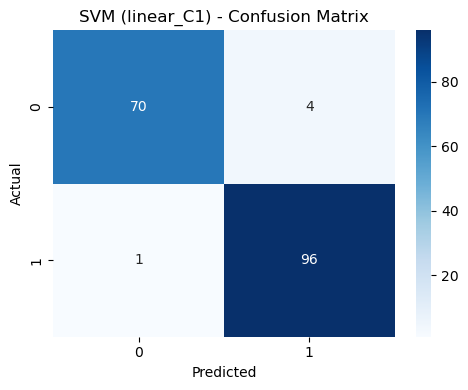

In [20]:
# pick the config with best F1
res_df_num = res_df.copy()
res_df_num['F1_num'] = res_df_num['F1'].astype(float)
best_label = res_df_num.loc[res_df_num['F1_num'].idxmax(), 'Config']
best_svm = svm_models[best_label]
print(f"Best configuration: {best_label}\n")

# evaluate best model on test set
y_pred_best = best_svm.predict(X_test_svm)
yt01 = ((y_test_svm + 1) / 2).astype(int)
yp01 = ((np.clip(y_pred_best, -1, 1) + 1) / 2).astype(int)

print_report(yt01, yp01, title=f"SVM - {best_label}")
plot_cm(yt01, yp01, labels=[0, 1], title=f"SVM ({best_label}) - Confusion Matrix")

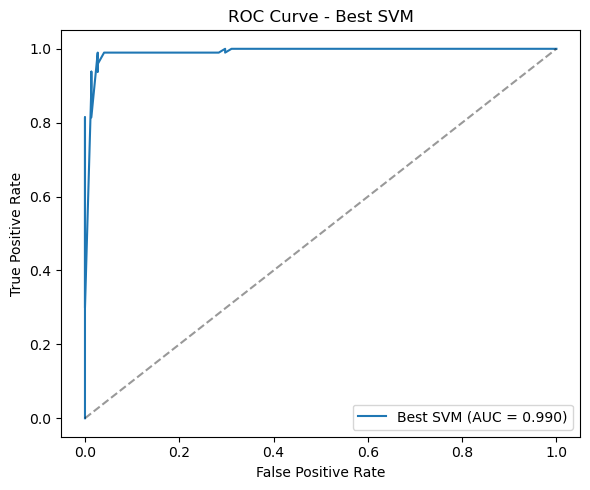

In [21]:
# ROC curve for best SVM
prob_best = best_svm.predict_proba_approx(X_test_svm)
fprs_svm, tprs_svm, auc_svm = roc_auc_manual(yt01, prob_best)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fprs_svm, tprs_svm, label=f'Best SVM (AUC = {auc_svm:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)  # random baseline
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Best SVM')
ax.legend()
plt.tight_layout()
plt.show()

### Analyze how different hyperparameters affect decision boundaries
### Visualize support vectors and decision boundaries for a 2D projection of your data 

Using mean radius and mean texture as the two features, we train an SVM with each kernel to see how the decision boundary looks in 2D.


  SVM fitted - 115 support vectors out of 398 samples
  SVM fitted - 120 support vectors out of 398 samples
  SVM fitted - 102 support vectors out of 398 samples


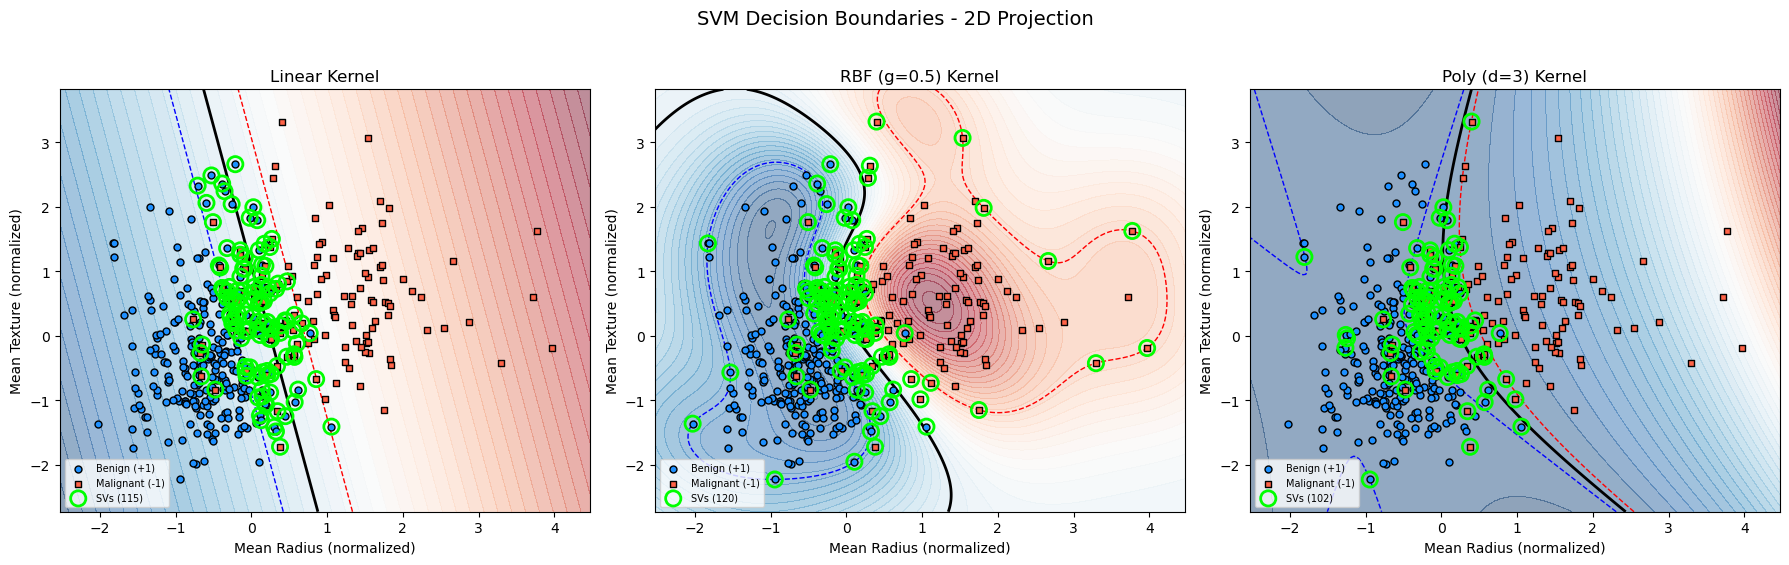

In [22]:
# pick 2 features for 2D visualization (mean_radius and mean_texture)
fi, fj = 0, 1
X_2d_tr = X_train_svm[:, [fi, fj]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# try one of each kernel type
kernel_cfgs = [
    ('Linear',      {'C': 1.0, 'kernel': 'linear', 'gamma': 0.1, 'degree': 3}),
    ('RBF (g=0.5)', {'C': 1.0, 'kernel': 'rbf',    'gamma': 0.5, 'degree': 3}),
    ('Poly (d=3)',  {'C': 1.0, 'kernel': 'poly',    'gamma': 0.1, 'degree': 3}),
]

for ax, (kname, params) in zip(axes, kernel_cfgs):
    # train a fresh SVM on just the 2 features
    svm2d = SVMClassifier(**params)
    svm2d.fit(X_2d_tr, y_train_svm)

    # create a grid to plot the decision surface
    margin = 0.5
    x_min, x_max = X_2d_tr[:, 0].min() - margin, X_2d_tr[:, 0].max() + margin
    y_min, y_max = X_2d_tr[:, 1].min() - margin, X_2d_tr[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = svm2d.decision_function(grid).reshape(xx.shape)

    # color the regions by decision value
    ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.45)
    # solid line = boundary, dashed = margins
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['red', 'black', 'blue'],
               linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

    # plot the training points
    pos = y_train_svm == 1
    neg = y_train_svm == -1
    ax.scatter(X_2d_tr[pos, 0], X_2d_tr[pos, 1], c='dodgerblue', edgecolors='k',
               marker='o', s=25, label='Benign (+1)', zorder=3)
    ax.scatter(X_2d_tr[neg, 0], X_2d_tr[neg, 1], c='tomato', edgecolors='k',
               marker='s', s=25, label='Malignant (-1)', zorder=3)

    # circle the support vectors in green
    sv = svm2d.support_vectors
    ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='lime',
               linewidths=2, label=f'SVs ({len(sv)})', zorder=4)

    ax.set_title(f'{kname} Kernel')
    ax.set_xlabel('Mean Radius (normalized)')
    ax.set_ylabel('Mean Texture (normalized)')
    ax.legend(fontsize=7, loc='lower left')

plt.suptitle('SVM Decision Boundaries - 2D Projection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Compare your implementation with scikit-learn's SVM (performance and efficiency), and previous logistic regression results

In [23]:
# train sklearn SVMs on the same training data for comparison
sk_lin = SkSVC(kernel='linear', C=1.0, random_state=42)
sk_lin.fit(X_train_svm, y_train_svm)
y_sk_lin = sk_lin.predict(X_test_svm)

sk_rbf = SkSVC(kernel='rbf', C=1.0, gamma=0.1, random_state=42)
sk_rbf.fit(X_train_svm, y_train_svm)
y_sk_rbf = sk_rbf.predict(X_test_svm)

# convert -1/+1 labels back to 0/1
to01 = lambda y: ((np.array(y) + 1) / 2).astype(int)
yt01 = to01(y_test_svm)

print("=" * 80)
print("  Our SVM  vs  Sklearn SVM  vs  Our Logistic Regression")
print("=" * 80)

rows_final = []

# our SVM models - linear baseline and whichever config scored best
for lbl in ['linear_C1', best_label]:
    if lbl in svm_models:
        yp = to01(svm_models[lbl].predict(X_test_svm))
        acc = accuracy_manual(yt01, yp)
        pr, rc, f1, _ = precision_recall_f1(yt01, yp)
        rows_final.append([f"Ours - {lbl}", f"{acc:.4f}", f"{pr.mean():.4f}",
                            f"{rc.mean():.4f}", f"{f1.mean():.4f}"])

# sklearn SVMs for reference
for name, yp in [("Sklearn - linear", y_sk_lin), ("Sklearn - rbf", y_sk_rbf)]:
    yp01 = to01(yp)
    acc = accuracy_manual(yt01, yp01)
    pr, rc, f1, _ = precision_recall_f1(yt01, yp01)
    rows_final.append([name, f"{acc:.4f}", f"{pr.mean():.4f}",
                        f"{rc.mean():.4f}", f"{f1.mean():.4f}"])

# using logistic regression from task 2
# note: this used a different test split so not a perfect comparision
acc_lr_f = accuracy_manual(y_test_lr.astype(int), y_pred_lr)
pr_lr, rc_lr, f1_lr, _ = precision_recall_f1(y_test_lr.astype(int), y_pred_lr)
rows_final.append(["Ours - LogReg", f"{acc_lr_f:.4f}", f"{pr_lr.mean():.4f}",
                    f"{rc_lr.mean():.4f}", f"{f1_lr.mean():.4f}"])

# output table
final_df = pd.DataFrame(rows_final, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
print(final_df.to_string(index=False))

  Our SVM  vs  Sklearn SVM  vs  Our Logistic Regression
           Model Accuracy Precision Recall     F1
Ours - linear_C1   0.9708    0.9730 0.9678 0.9701
Ours - linear_C1   0.9708    0.9730 0.9678 0.9701
Sklearn - linear   0.9708    0.9730 0.9678 0.9701
   Sklearn - rbf   0.9532    0.9524 0.9524 0.9524
   Ours - LogReg   0.9419    0.9473 0.9331 0.9389


## Analysis - Task 3

### How hyperparameters affect the decision boundary

Higher C forces the model to classify more points correctly, so the margin gets 
tighter. Lower C allows a wider margin and some misclassifications, which tends 
to generalize better.

Linear kernel works when the classes are already separable. RBF bends the 
boundary around clusters, which you can see in the 2D plots. Polynomial (d=3) 
is somewhere in between.

Small gamma (0.01) produces a smooth, almost linear boundary. Larger gamma 
(0.1+) makes the boundary follow the training points more closely, which 
risks overfitting.

### Our SVM vs sklearn

Results are close. The differences come from the optimizer. We use scipy's 
SLSQP, while sklearn uses libsvm with the SMO algorithm, which is built 
specifically for SVMs and handles larger datasets more efficiently.

### SVM vs logistic regression

Both do well here since the data is mostly linearly separable.

RBF kernel gives SVM a slight edge in some configs because it can pick up 
non-linear patterns that logistic regression misses.

Logistic regression gives you calibrated probabilities out of the box. For 
SVM we had to approximate them with a sigmoid on the decision values, which 
is less reliable.

Logistic regression is also faster and easier to interpret since you can 
read the weight vector directly to see which features matter.